# Quantitative Financial Analysis & Factor Modeling with PCA

**Project Objective:** This project explores the S&P 500 stock market data using Python. The first phase focuses on foundational financial metrics (daily returns, volatility, cumulative growth, and correlations) for major tech stocks. The second phase applies unsupervised machine learning (Principal Component Analysis) to the broader market to identify hidden macroeconomic factors driving stock returns.

**Skills Demonstrated:** Data Cleaning, Financial Time-Series Analysis, Machine Learning (PCA), Data Visualization.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Display settings for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# List input files (Kaggle environment setup)
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_stocks.csv
/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_companies.csv
/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_index.csv


In [4]:
# 1. Load the dataset
stocks_path = "/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_stocks.csv"
df = pd.read_csv(stocks_path)

# 2. Standardize columns and datetime
df.columns = df.columns.str.lower().str.replace(" ", "_")
df["date"] = pd.to_datetime(df["date"])

# 3. Handle Missing Values
df_clean = df.dropna(subset=["close"]).copy()
df_clean = df_clean.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"Dataset cleaned. Analyzing {df_clean['symbol'].nunique()} stocks from {df_clean['date'].min().date()} to {df_clean['date'].max().date()}.")

Dataset cleaned. Analyzing 172 stocks from 2010-01-04 to 2024-12-20.


## Phase 1: Foundational Analysis on Major Tech Stocks
Before scaling to the entire market, we will analyze the risk, return, and correlation of a specific basket of market leaders: Amazon, Microsoft, and Nvidia.

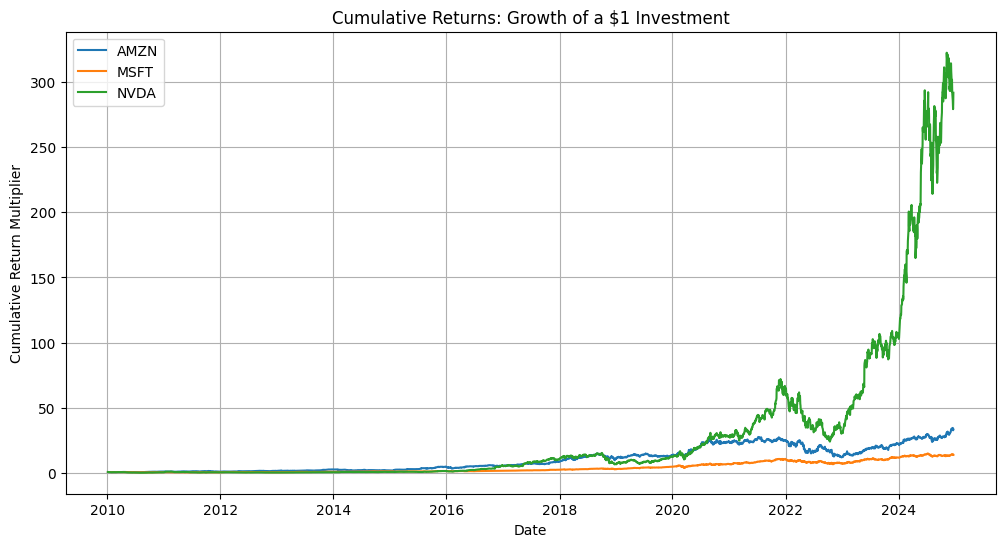

In [5]:
selected_stocks = ["AMZN", "MSFT", "NVDA"]
selected_df = df_clean[df_clean["symbol"].isin(selected_stocks)].copy()

# Calculate Daily Returns
selected_df["daily_return"] = selected_df.groupby("symbol")["close"].pct_change()

# Calculate Cumulative Returns (Growth of a $1 investment)
selected_df["cumulative_return"] = (
    selected_df
    .groupby("symbol")["daily_return"]
    .transform(lambda x: (1 + x).cumprod())
)

# Visualize Cumulative Returns
plt.figure(figsize=(12, 6))
for stock in selected_stocks:
    stock_data = selected_df[selected_df["symbol"] == stock].dropna(subset=["cumulative_return"])
    plt.plot(stock_data["date"], stock_data["cumulative_return"], label=stock)

plt.title("Cumulative Returns: Growth of a $1 Investment")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Multiplier")
plt.legend()
plt.grid(True)
plt.show()

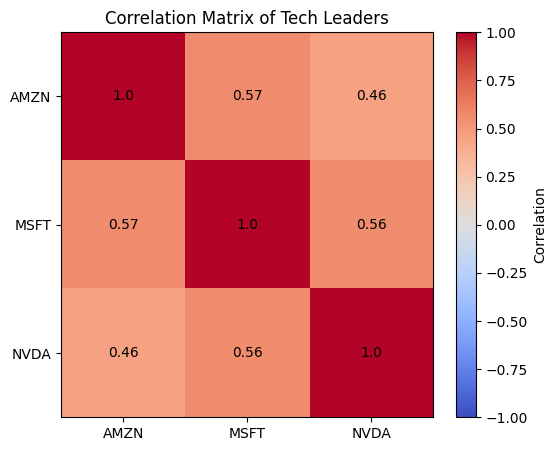

In [6]:
# Create a pivot table for correlation analysis
returns_pivot = selected_df.pivot(index="date", columns="symbol", values="daily_return")
correlation_matrix = returns_pivot.corr()

# Visualize the Correlation Matrix
plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(ticks=range(len(correlation_matrix.columns)), labels=correlation_matrix.columns)
plt.yticks(ticks=range(len(correlation_matrix.index)), labels=correlation_matrix.index)
plt.title("Correlation Matrix of Tech Leaders")

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, round(correlation_matrix.iloc[i, j], 2), ha="center", va="center", color="black")
plt.show()

## Phase 2: Identifying Market Drivers with PCA
Individual stock analysis is useful, but the broader market is driven by unobservable macroeconomic variables (factors). We will use Principal Component Analysis (PCA) on the entire S&P 500 dataset to extract these hidden market factors.

**Steps:**
1. Pivot the dataset into a matrix of daily returns for all stocks.
2. Filter out stocks with excessive missing data.
3. Standardize the data so volatile stocks don't dominate the algorithm.
4. Fit the PCA model to extract the principal components.

In [7]:
# 1. Create a wide matrix of all available stocks
all_returns_matrix = df_clean.pivot(index="date", columns="symbol", values="close").pct_change().iloc[1:]

# 2. Filter out stocks with too many missing values (require 95% complete data)
threshold = int(len(all_returns_matrix) * 0.95)
all_returns_matrix = all_returns_matrix.dropna(thresh=threshold, axis=1)

# 3. Drop remaining dates that have NaNs to create a clean, dense matrix
all_returns_matrix = all_returns_matrix.dropna(axis=0)

print(f"Final Matrix for PCA: {all_returns_matrix.shape[1]} stocks over {all_returns_matrix.shape[0]} trading days.")

# 4. Standardize the return series (mean = 0, variance = 1)
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(all_returns_matrix)
scaled_returns_df = pd.DataFrame(scaled_returns, index=all_returns_matrix.index, columns=all_returns_matrix.columns)

Final Matrix for PCA: 151 stocks over 3645 trading days.


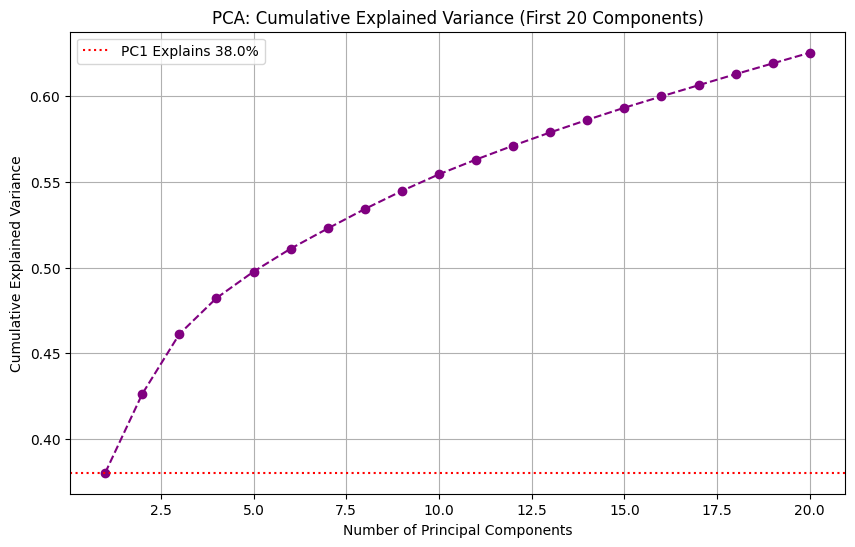

In [8]:
# Fit PCA to the standardized returns
pca = PCA()
pca.fit(scaled_returns_df)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualize the Scree Plot (Cumulative Variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), cumulative_variance[:20], marker='o', linestyle='--', color='purple')
plt.title('PCA: Cumulative Explained Variance (First 20 Components)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=cumulative_variance[0], color='r', linestyle=':', label=f'PC1 Explains {explained_variance[0]*100:.1f}%')
plt.legend()
plt.grid(True)
plt.show()

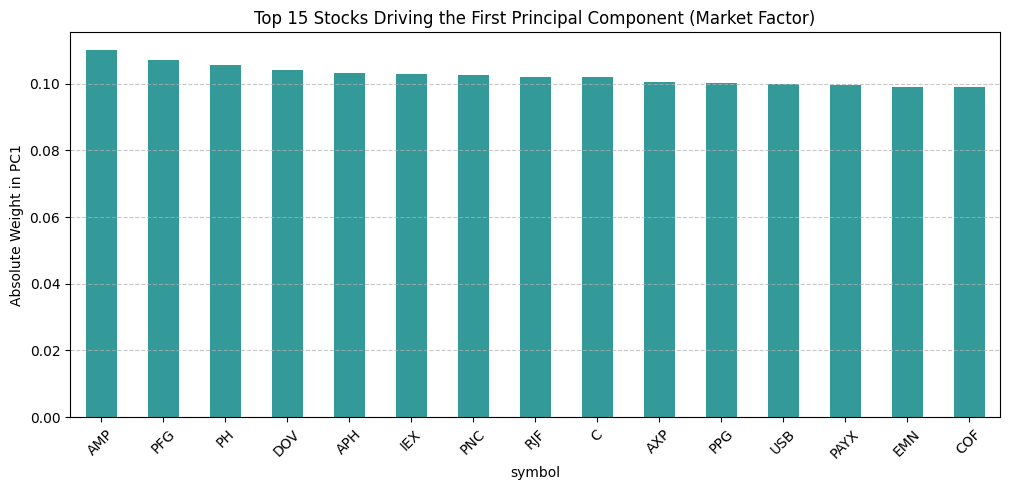

In [9]:
# PC1 typically represents the overall "Market Factor"
# Let's extract the weights to see which stocks drive this component the most
pc1_weights = pd.Series(pca.components_[0], index=all_returns_matrix.columns)

# Sort by absolute weight to find the strongest influencers
pc1_sorted = pc1_weights.abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
pc1_sorted.head(15).plot(kind='bar', color='teal', alpha=0.8)
plt.title('Top 15 Stocks Driving the First Principal Component (Market Factor)')
plt.ylabel('Absolute Weight in PC1')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

## Conclusion
1. **Tech Stock Dynamics:** AMZN, MSFT, and NVDA show high long-term cumulative growth, with significant positive correlation, indicating they often move together during broader tech trends.
2. **Market Factor:** Through PCA, we discovered that the first principal component (PC1) explains a massive portion of the variance across hundreds of stocks. In quantitative finance, this primary component is widely accepted as the overall "Market Factor," demonstrating how heavily correlated individual equities are to the broader macroeconomic environment.